In [ ]:
import numpy as np

In [ ]:
!pip install geopandas
!pip install pykrige

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 25.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
import tensorflow as tf
from keras import layers, models
from sklearn.pipeline import Pipeline
import pykrige #biblioteca de geoestadística
import pykrige.kriging_tools as kt #herramientas para exportar e importar archivos .asc con biblioteca PyKrige
from pykrige.ok import OrdinaryKriging #Kriging Ordinario con PyKrige

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


forecasting

In [ ]:
path="/content/drive/MyDrive/investigacion/datasetLC"
df=pd.read_csv(path+"/dataset2005-01-09.csv")
df.head()

,lat,lon,band1,band2,band3,band4,band5,band6,band7,irradiance
0,-8789850.0,184950.0,2790.0813,4296.806168,2872.552727,2930.404799,4249.742666,3006.705973,1823.397754,206.626943
1,-8784900.0,174600.0,2790.0813,4296.806168,2872.552727,2930.404799,4249.742666,3006.705973,1823.397754,205.608576
2,-8775000.0,169650.0,3114.1877,4332.650201,3231.588515,3286.695698,4235.390294,3102.295887,1894.808666,194.739615
3,-8775000.0,174600.0,2790.0813,4296.806168,2872.552727,2930.404799,4249.742666,3006.705973,1823.397754,204.346091
4,-8775000.0,184950.0,2790.0813,4296.806168,2872.552727,2930.404799,4249.742666,3006.705973,1823.397754,204.887983


In [ ]:
min_lat=df["lat"].min()
max_lat=df["lat"].max()
min_lon=df["lon"].min()
max_lon=df["lon"].max()
print(min_lat,max_lat,min_lon,max_lon)

-8789850.0 -8554950.0 45000.0 294750.0


In [ ]:
lat=df['lat'].unique()
lon=df['lon'].unique()

lat=np.sort(lat)
lon=np.sort(lon)
dif_lat=np.diff(lat)
dif_lon=np.diff(lon)

min_dif_lat=np.min(dif_lat)
min_dif_lon=np.min(dif_lon)

print(min_dif_lat,min_dif_lon)

4950.0 4950.0


In [ ]:

def get_images(df,max_lat,min_lat,max_lon,min_lon):
  rows = int(np.ceil((max_lat - min_lat) / 4950)) + 1
  cols = int(np.ceil((max_lon - min_lon) / 4950)) + 1
  matrix_b1 = np.zeros((cols, rows))
  matrix_b2 = np.zeros((cols, rows))
  matrix_b3 = np.zeros((cols, rows))
  matrix_b4 = np.zeros((cols, rows))
  matrix_b5 = np.zeros((cols, rows))
  matrix_b6 = np.zeros((cols, rows))
  matrix_b7 = np.zeros((cols, rows))
  matrix_b8 = np.zeros((cols, rows))
  matrix_irradiance = np.zeros((cols, rows))

  # Llenar la matriz con los valores de irradiancia
  for index, row in df.iterrows():
      lat_index = int(np.floor((row['lat'] - min_lat) / 4950))
      lon_index = int(np.floor((max_lon-row['lon']) / 4950))
      if 0 <= lat_index < rows and 0 <= lon_index < cols:
        matrix_b1[lon_index, lat_index] = row['band1']
        matrix_b2[lon_index, lat_index] = row['band2']
        matrix_b3[lon_index, lat_index] = row['band3']
        matrix_b4[lon_index, lat_index] = row['band4']
        matrix_b5[lon_index, lat_index] = row['band5']
        matrix_b6[lon_index, lat_index] = row['band6']
        matrix_b7[lon_index, lat_index] = row['band7']
        matrix_b8[lon_index, lat_index] = row['irradiance']

        matrix_irradiance[lon_index, lat_index] = row['irradiance']

  satelital_image = np.stack((matrix_b1, matrix_b2, matrix_b3, matrix_b4, matrix_b5, matrix_b6, matrix_b7), axis=-1)
  return satelital_image,matrix_irradiance

def get_dataframe(df,matrix,max_lat,min_lat,max_lon,min_lon):
  rows = int(np.ceil((max_lat - min_lat) / 4950)) + 1
  cols = int(np.ceil((max_lon - min_lon) / 4950)) + 1
  lat=[]
  lon=[]
  irradiance=[]
  # Llenar la matriz con los valores de irradiancia
  for index, row in df.iterrows():
      lat_index = int(np.floor((row['lat'] - min_lat) / 4950))
      lon_index = int(np.floor((max_lon-row['lon']) / 4950))
      if 0 <= lat_index < rows and 0 <= lon_index < cols:
        lat.append(row['lat'])
        lon.append(row['lon'])
        irradiance.append(matrix[lon_index, lat_index])

  df_result=pd.DataFrame({'latitude':lat,'longitude':lon,'irradiance':irradiance})
  return df_result

In [ ]:
satelital_image,matrix_irradiance=get_images(df,max_lat,min_lat,max_lon,min_lon)
satelital_image.shape,matrix_irradiance.shape

((52, 49, 7), (52, 49))

In [ ]:
#nombre dce columnas
print(df.columns)

Index(['lat', 'lon', 'band1', 'band2', 'band3', 'band4', 'band5', 'band6',
       'band7', 'irradiance'],
      dtype='object')


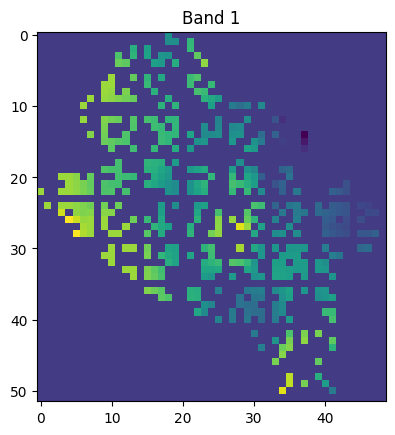

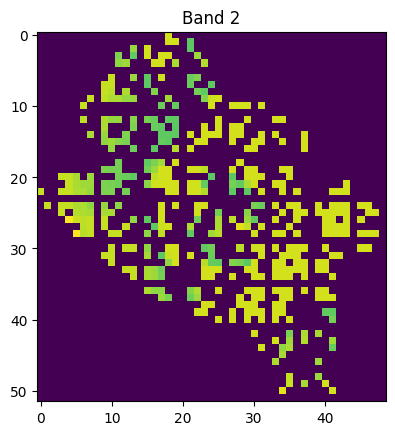

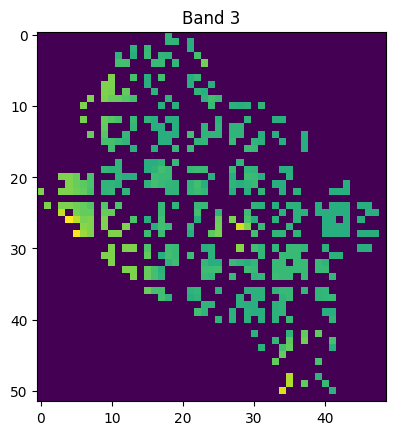

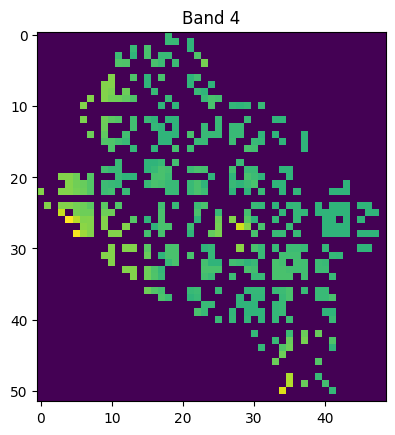

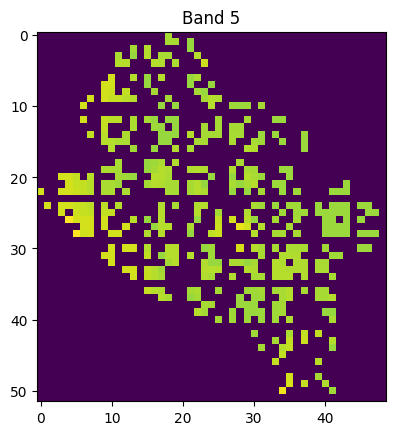

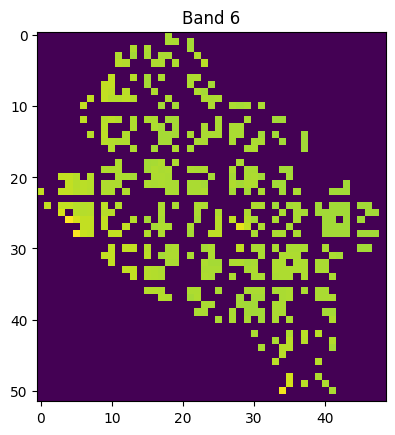

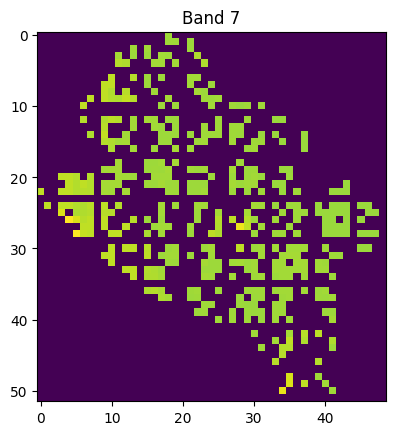

In [ ]:
for i in range(satelital_image.shape[2]):
  plt.title(f"Band {i+1}")
  plt.imshow(satelital_image[:,:,i])
  plt.show()

In [ ]:
X=[]
y=[]
dates=[]
for filename in os.listdir(path):
  print(filename)
  if filename.endswith(".csv"):
    print("read file")
    df=pd.read_csv(path+"/"+filename)
    dates.append(filename.split(".")[0])
    print("get images 2 dataframe")
    satelital_image,matrix_irradiance=get_images(df,max_lat,min_lat,max_lon,min_lon)
    print("append images")
    X.append(satelital_image)
    y.append(matrix_irradiance)


dataset2007-11-11.csv
read file
get images 2 dataframe
append images
dataset2007-11-18.csv
read file
get images 2 dataframe
append images
dataset2007-11-25.csv
read file
get images 2 dataframe
append images
dataset2007-12-02.csv
read file
get images 2 dataframe
append images
dataset2007-12-09.csv
read file
get images 2 dataframe
append images
dataset2007-12-16.csv
read file
get images 2 dataframe
append images
dataset2007-12-23.csv
read file
get images 2 dataframe
append images
dataset2007-12-30.csv
read file
get images 2 dataframe
append images
dataset2008-01-06.csv
read file
get images 2 dataframe
append images
dataset2008-01-13.csv
read file
get images 2 dataframe
append images
dataset2008-01-20.csv
read file
get images 2 dataframe
append images
dataset2008-01-27.csv
read file
get images 2 dataframe
append images
dataset2008-02-03.csv
read file
get images 2 dataframe
append images
dataset2008-02-10.csv
read file
get images 2 dataframe
append images
dataset2008-02-17.csv
read file
ge

In [ ]:
df

,lat,lon,band1,band2,band3,band4,band5,band6,band7,irradiance
0,-8789850.0,184950.0,1858.1122,4132.022687,2325.464760,2465.765441,3975.699130,2908.757556,1732.102615,214.630342
1,-8784900.0,174600.0,1971.9077,3597.001757,2248.132107,2356.354544,3852.967634,2862.215809,1721.457722,214.822655
2,-8775000.0,169650.0,1903.1478,3897.204968,2320.801086,2426.722917,3947.733366,2900.053869,1725.747886,214.710914
3,-8775000.0,174600.0,1978.6503,3580.397894,2248.132107,2356.354544,3852.967634,2862.215809,1721.457722,214.867645
4,-8775000.0,184950.0,2001.8030,3542.764872,2248.132107,2356.354544,3852.967634,2862.215809,1721.457722,214.849467
...,...,...,...,...,...,...,...,...,...,...
440,-8559900.0,154800.0,2776.5583,4285.591178,2872.552727,2930.404799,4249.742666,3006.705973,1823.397754,231.766402
441,-8559900.0,169650.0,2400.6690,4037.238966,2514.538568,2611.111591,4049.468344,2928.249879,1771.278741,238.357094
442,-8559900.0,174600.0,2282.3840,3801.664932,2376.350065,2507.336480,3994.738982,2912.450352,1734.711126,240.945771
443,-8554950.0,154800.0,2916.9110,4217.998169,3023.498658,3074.688459,4226.428845,3028.295523,1836.341753,228.888384


In [ ]:
new_dates = []
for date in dates:
  new_dates.append(date.replace("dataset","").replace("landsat", ""))

In [ ]:
#convert str to date
from datetime import datetime
new_dates = [datetime.strptime(date, '%Y-%m-%d') for date in new_dates]

In [ ]:
X=np.array(X)

In [ ]:
y=np.array(y)

In [ ]:
X.shape,y.shape

((1148, 52, 49, 7), (1148, 52, 49))

In [ ]:
new_dates=np.array(new_dates)
index=np.argsort(new_dates)
X=X[index]
y=y[index]

In [ ]:
#min max scaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X = scaler.fit_transform(X.reshape(-1, X.shape[-1])).reshape(X.shape)
X.shape

(1148, 52, 49, 7)

In [ ]:
y=scaler.fit_transform(y.reshape(-1, 1)).reshape(y.shape)
y.shape

(1148, 52, 49)

In [ ]:
X.min(),X.max(),y.min(),y.max()

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

windows


In [ ]:
#forecasting window
def window(X,y,v):
  yt=y[v:]
  Xt=[]
  for i in range(X.shape[0]-v):
    Xt.append(X[i:i+v])

  return np.array(Xt),yt

In [ ]:
Xt,yt=window(X,y,15)
Xt.shape,yt.shape

((1133, 15, 52, 49, 7), (1133, 52, 49))

In [ ]:
Xt.shape[1:]

(15, 52, 49, 7)

In [ ]:
Xt.shape

(1133, 15, 52, 49, 7)

In [ ]:
Xtrain=Xt[:int(0.8*Xt.shape[0])]
ytrain=yt[:int(0.8*yt.shape[0])]

Xtest=Xt[int(0.8*Xt.shape[0]):]
ytest=yt[int(0.8*yt.shape[0]):]

In [ ]:
X_train=Xtrain[:int(0.8*Xtrain.shape[0])]
y_train=ytrain[:int(0.8*ytrain.shape[0])]

X_test=Xtrain[int(0.8*Xtrain.shape[0]):]
y_test=ytrain[int(0.8*ytrain.shape[0]):]

model

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, ConvLSTM2D, Conv2D, BatchNormalization, Dropout

inputs = Input(shape=(Xt.shape[1:]))  # ventana temporal, alto, ancho, canales

x = ConvLSTM2D(filters=32, kernel_size=(3, 3), padding='same', return_sequences=False, activation='relu')(inputs)
x = BatchNormalization()(x)             # Normalización para estabilizar
x = Dropout(0.3)(x)                     # Dropout para evitar sobreajuste

x = Conv2D(filters=16, kernel_size=(3, 3), padding='same', activation='relu')(x)
x = BatchNormalization()(x)             # Otra capa de normalización
x = Dropout(0.3)(x)                     # Más dropout

outputs = Conv2D(filters=1, kernel_size=(3, 3), padding='same', activation='linear')(x)

model = Model(inputs, outputs)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 15, 52, 49, 7)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d (ConvLSTM2D)        │ (None, 52, 49, 32)     │        45,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 52, 49, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 52, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 52, 49, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 52, 49, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 52, 49, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 52, 49, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,017 (195.38 KB)

 Trainable params: 49,921 (195.00 KB)

 Non-trainable params: 96 (384.00 B)

In [ ]:
path="/content/drive/MyDrive/investigacion/windows"


In [ ]:
import time
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.metrics import MeanAbsoluteError

early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=10, min_lr=1e-8)
checkpoint= ModelCheckpoint(filepath=path+'model.keras', monitor='val_loss', save_best_only=True)

start_time = time.time()
history = model.fit(Xtrain, ytrain, epochs=1000, batch_size=32,validation_data=(X_test,y_test), callbacks=[early_stopping, reduce_lr,checkpoint])
end_time = time.time()
total_training_time = end_time - start_time
print(f"\nTotal training time: {total_training_time:.2f} seconds")

Epoch 1/1000
29/29 ━━━━━━━━━━━━━━━━━━━━ 22s 462ms/step - loss: 1.7524 - mae: 0.9635 - val_loss: 0.0776 - val_mae: 0.2447 - learning_rate: 0.0010
Epoch 2/1000
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 200ms/step - loss: 0.6983 - mae: 0.6036 - val_loss: 0.0761 - val_mae: 0.2596 - learning_rate: 0.0010
Epoch 3/1000
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 196ms/step - loss: 0.4668 - mae: 0.4964 - val_loss: 0.0740 - val_mae: 0.2485 - learning_rate: 0.0010
Epoch 4/1000
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 200ms/step - loss: 0.3312 - mae: 0.4249 - val_loss: 0.0725 - val_mae: 0.2392 - learning_rate: 0.0010
Epoch 5/1000
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 197ms/step - loss: 0.2394 - mae: 0.3653 - val_loss: 0.0668 - val_mae: 0.2236 - learning_rate: 0.0010
Epoch 6/1000
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 201ms/step - loss: 0.1730 - mae: 0.3128 - val_loss: 0.0610 - val_mae: 0.2074 - learning_rate: 0.0010
Epoch 7/1000
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 198ms/step - loss: 0.1255 - mae: 0.2673 - val_loss: 0.0556 - val_mae: 0.1896 - learning_rat

### Medición del Tiempo de Inferencia

El tiempo de inferencia es el tiempo que tarda el modelo en realizar una predicción sobre un nuevo conjunto de datos. Es importante medirlo para entender la eficiencia del modelo en producción. Aquí te muestro cómo puedes medirlo para tu modelo.

In [ ]:
import time

# Tomar una muestra del conjunto de prueba para la inferencia
# Por ejemplo, la primera muestra del conjunto de prueba
sample_for_inference = Xtest[0:1]

# Medir el tiempo de inferencia para una única predicción
start_inference_time = time.time()
_ = model.predict(sample_for_inference)
end_inference_time = time.time()
single_inference_time = end_inference_time - start_inference_time
print(f"Tiempo de inferencia para una sola muestra: {single_inference_time:.4f} segundos")

# Medir el tiempo de inferencia para todo el conjunto de prueba
start_batch_inference_time = time.time()
y_pred_inference = model.predict(Xtest)
end_batch_inference_time = time.time()
batch_inference_time = end_batch_inference_time - start_batch_inference_time
print(f"Tiempo de inferencia para el conjunto de prueba (en batch): {batch_inference_time:.4f} segundos")
print(f"Promedio por muestra en batch: {batch_inference_time / Xtest.shape[0]:.4f} segundos")

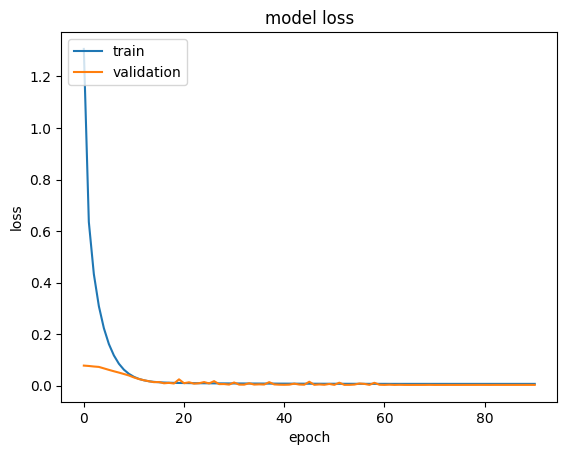

In [ ]:
#plot history
import matplotlib.pyplot as plt
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')


In [ ]:
model.evaluate(Xtest,ytest)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step - loss: 0.0026 - mae: 0.0176


[0.002541341120377183, 0.017575005069375038]

In [ ]:
ytest.shape

(227, 52, 49)

In [ ]:
#r2 score
from sklearn.metrics import r2_score
n=ytest.shape[0]
y_pred = model.predict(Xtest)
y_pred[ytest==0]=0
r2_score(ytest.reshape(n,-1), y_pred.reshape(n,-1))

8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 185ms/step


0.7201606626466376

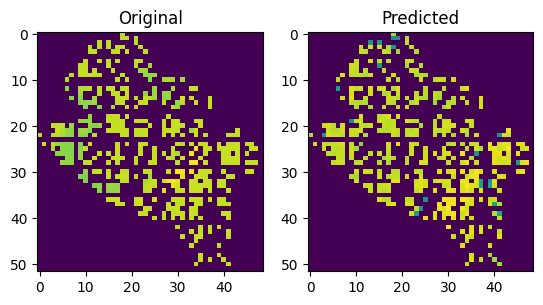

In [ ]:
plt.subplot(1, 2, 1)
plt.title('Original')
plt.imshow(ytest[90])
plt.subplot(1, 2, 2)
plt.title('Predicted')
plt.imshow(y_pred[90])
plt.show()